# Funciones de distribucion de probabilidades

## Distribucion Uniforme

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
a = 1
b = 100
n = 1000000

data = np.random.uniform(a, b, n)

(array([ 99935., 100045., 100063.,  99817., 100230.,  99804., 100255.,
        100227.,  99513., 100111.]),
 array([ 1.0000142 , 10.90000962, 20.80000504, 30.70000046, 40.59999588,
        50.49999129, 60.39998671, 70.29998213, 80.19997755, 90.09997297,
        99.99996839]),
 <BarContainer object of 10 artists>)

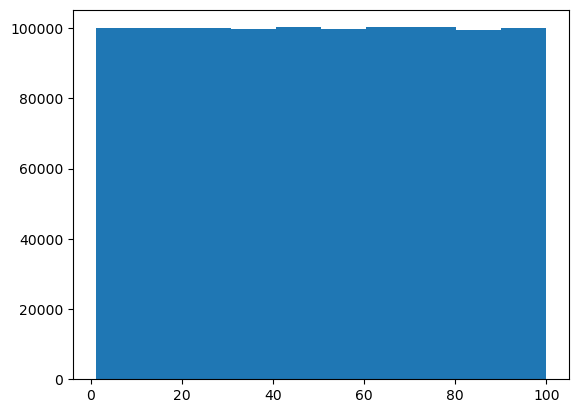

In [14]:
plt.hist(data)

## Distribucion Normal

In [19]:
data = np.random.randn(1000000)

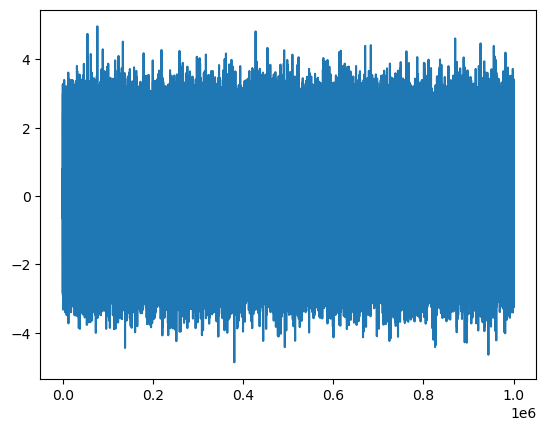

In [22]:
x = range(1, 1000001)

plt.plot(x, data)

(array([5.00000e+01, 1.81200e+03, 2.60270e+04, 1.47873e+05, 3.44799e+05,
        3.29569e+05, 1.28332e+05, 2.02250e+04, 1.27400e+03, 3.90000e+01]),
 array([-4.86628406, -3.88250701, -2.89872996, -1.91495291, -0.93117586,
         0.05260119,  1.03637824,  2.02015529,  3.00393234,  3.98770939,
         4.97148644]),
 <BarContainer object of 10 artists>)

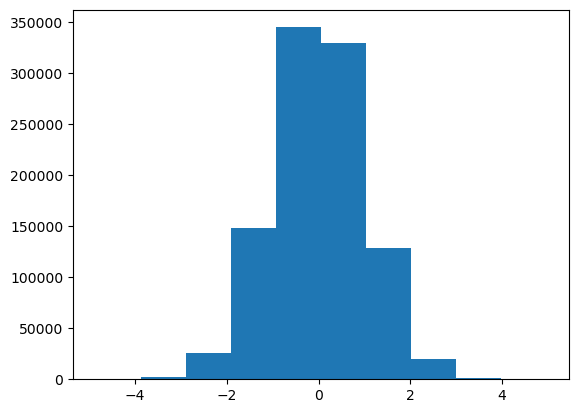

In [23]:
plt.hist(data)

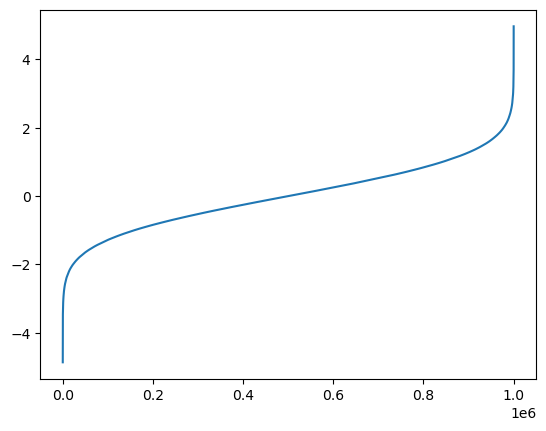

In [24]:
# Output => Funcion de distribucion acumulada
plt.plot(x, sorted(data))

(array([   6.,   46.,  315., 1183., 2496., 2959., 1984.,  792.,  193.,
          26.]),
 array([-4.79260393, -2.86668531, -0.94076669,  0.98515193,  2.91107055,
         4.83698916,  6.76290778,  8.6888264 , 10.61474502, 12.54066364,
        14.46658226]),
 <BarContainer object of 10 artists>)

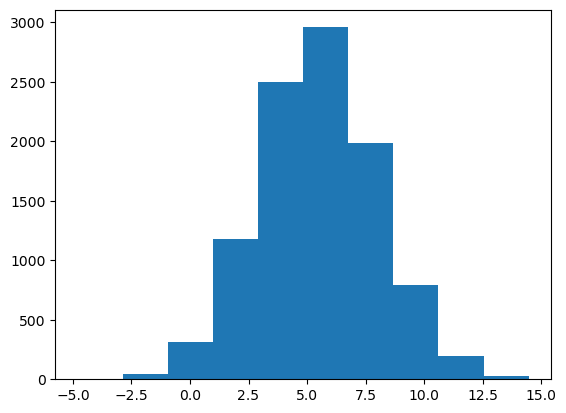

In [26]:
mu = 5.5
sd = 2.5
Z_10000 = np.random.randn(10000)
"""
    Teorema central del limite (tipificar)
    Z = (X - mu) / sd => N(0,1), X = mu + sd * Z
"""
data = mu + sd * Z_10000 
plt.hist(data)

In [27]:
data = np.random.randn(2, 4)
data

array([[-1.09585504, -1.28675676,  0.58124471, -1.77464985],
       [ 1.36175944,  1.00426499,  0.20624328,  0.01642939]])

## La simulacion de Monte Carlo

* Generamos dos numeros aleatorios uniformes (x e y) entre 0 y 1 en total 1000000 veces
* Calculamos x^2 + y^2
  * Si valor es inferior a 1 -> Estamos dentro del circulo
  * Si el valor es superior a 1 -> Estamos fuera del circulo
* Calculamos el numero total de veces que estan dentro del circulo y lo dividimos entre el numero total de intentos para obtener una aproximacion de la probabilidad de caer dentro del circulo.
* Usamos dicha probabilidad para aproximar el valor de pi
* Repetimos el experimento un numero suficiente de veces (por ejemplo 100), para obtener diferentes aproximaciones de pi
* Calculamos el promedio de los 100 exprerimentosanteriores para dar un valor final de pi 

In [32]:
def pi_montecarlo(n, n_exp):
    pi_avg = 0
    pi_value_list = []
    for i in range(n_exp):
        value = 0
        x = np.random.uniform(0, 1, n).tolist()
        y = np.random.uniform(0, 1, n).tolist()
        for j in range(n):
            z = np.sqrt(x[j] * x[j] + y[j] * y[j])
            if z <= 1:
                value += 1
        float_value = float(value)
        pi_value = float_value * 4 / n
        pi_value_list.append(pi_value)
        pi_avg += pi_value
    
    pi = pi_avg/n_exp
    fig = plt.plot(pi_value_list)
    return (pi, fig)

(3.1415583000000002, [<matplotlib.lines.Line2D at 0x7fa7e3590ec0>])

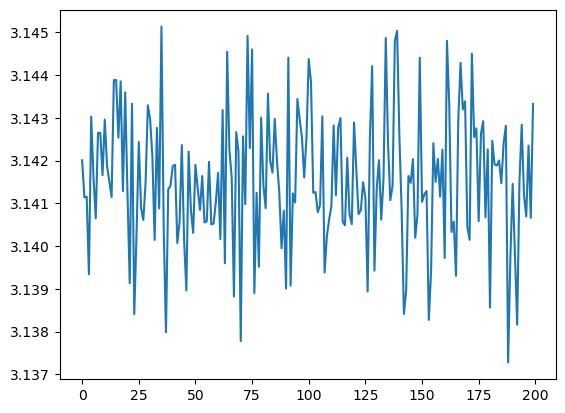

In [33]:
pi_montecarlo(1000000, 200)

## Dummy Data Sets

In [40]:
n = 1000000
data = pd.DataFrame(
    {
        "A": np.random.randn(n),
        "B": 1.5 + 2.5 * np.random.randn(n),
        "C": np.random.uniform(5, 32, n)
    }
)

In [41]:
data.describe()

,A,B,C
count,1000000.000000,1000000.000000,1000000.000000
mean,-0.000720,1.502030,18.503706
std,1.000205,2.502204,7.799235
min,-4.874943,-9.931408,5.000016
25%,-0.674002,-0.184468,11.737734
50%,-0.000647,1.502903,18.508905
75%,0.672605,3.193169,25.260861
max,4.701954,12.348487,31.999974


(array([4.40000e+01, 1.53300e+03, 2.12770e+04, 1.25288e+05, 3.17684e+05,
        3.42789e+05, 1.57376e+05, 3.13780e+04, 2.54600e+03, 8.50000e+01]),
 array([-4.87494349, -3.91725376, -2.95956403, -2.0018743 , -1.04418457,
        -0.08649484,  0.87119489,  1.82888462,  2.78657435,  3.74426408,
         4.70195381]),
 <BarContainer object of 10 artists>)

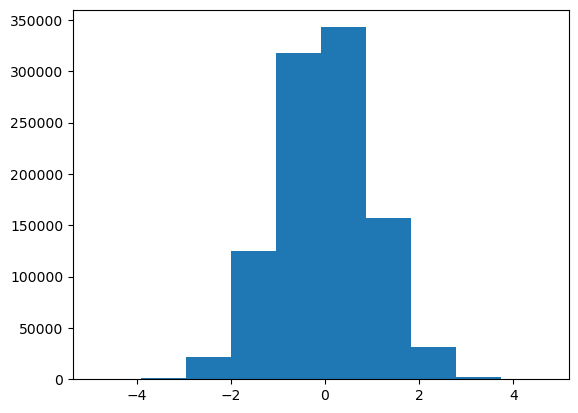

In [42]:
plt.hist(data["A"])

(array([1.16000e+02, 2.54100e+03, 2.64460e+04, 1.27690e+05, 2.96521e+05,
        3.26492e+05, 1.72246e+05, 4.26410e+04, 4.99900e+03, 3.08000e+02]),
 array([-9.93140788, -7.70341843, -5.47542897, -3.24743952, -1.01945006,
         1.20853939,  3.43652885,  5.6645183 ,  7.89250776, 10.12049721,
        12.34848667]),
 <BarContainer object of 10 artists>)

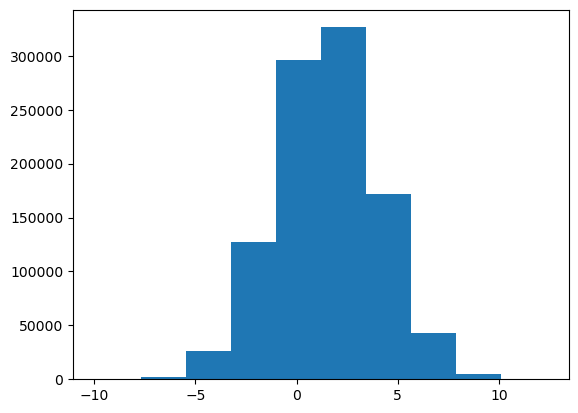

In [43]:
plt.hist(data["B"])

(array([ 99869., 100493., 100085.,  99743.,  99506.,  99723.,  99920.,
        100122., 100375., 100164.]),
 array([ 5.00001565,  7.70001149, 10.40000732, 13.10000316, 15.79999899,
        18.49999483, 21.19999067, 23.8999865 , 26.59998234, 29.29997818,
        31.99997401]),
 <BarContainer object of 10 artists>)

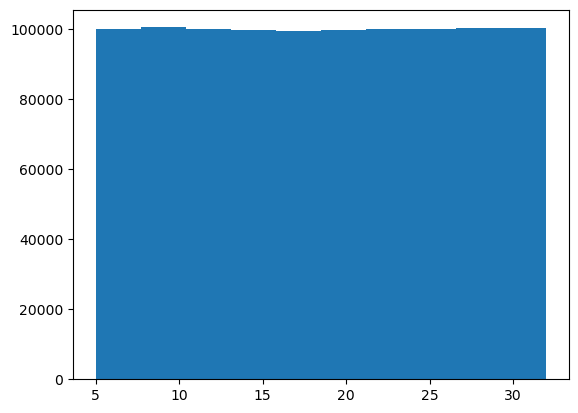

In [44]:
plt.hist(data["C"])

In [45]:
data = pd.read_csv('../resources/datasets/customer-churn-model/Customer Churn Model.txt')

In [46]:
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [48]:
column_names = data.columns.values.tolist()

In [49]:
a = len(column_names)
a

21

In [52]:
new_data = pd.DataFrame(
    {
        "Column Name": column_names,
        "A": np.random.randn(a),
        "B": np.random.uniform(0, 1, a)
    }, index = range(42, 42 + a)
)

In [53]:
new_data

,Column Name,A,B
42,State,0.079302,0.661744
43,Account Length,2.101436,0.893222
44,Area Code,-0.208066,0.426414
45,Phone,0.457383,0.429445
46,Int'l Plan,1.614090,0.698887
47,VMail Plan,0.383075,0.257336
48,VMail Message,-0.017538,0.128369
49,Day Mins,-0.730669,0.570488
50,Day Calls,0.355698,0.598118
51,Day Charge,0.015566,0.747031
